<a href="https://colab.research.google.com/github/sabbirpuspo/LearningforMe/blob/main/Medical_Image_Segmentation_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests

url = "https://www.kaggle.com/api/v1/datasets/download/mahmudulhasantasin/isic-2016-original-dataset"

r = requests.get(url)

print("Status:", r.status_code)
print("Size:", len(r.content))

Status: 200
Size: 871972194


In [ ]:
import requests

url = "https://www.kaggle.com/api/v1/datasets/download/mahmudulhasantasin/isic-2016-original-dataset"

r = requests.get(url)

print("Status:", r.status_code)
print("Size:", len(r.content))

Status: 200
Size: 871972194


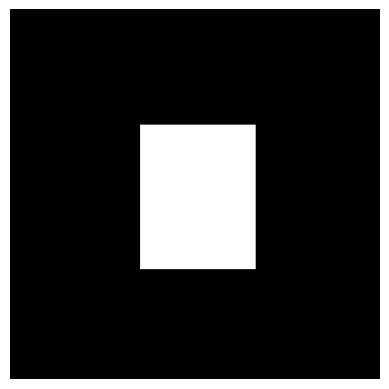

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

image = np.zeros((256, 256))

image[80:180, 90:170] = 1

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

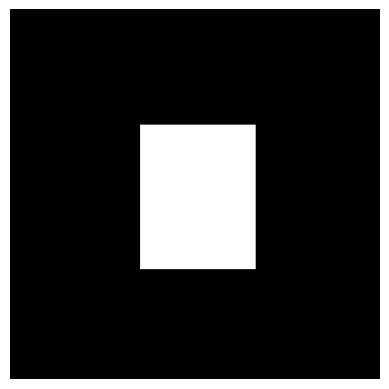

In [ ]:
mask = np.zeros((256, 256))

mask[80:180, 90:170] = 1

plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

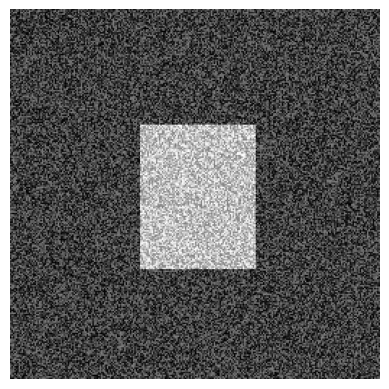

In [ ]:
image = np.random.rand(256, 256)

image[80:180, 90:170] += 1

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
print("I am learning medical image segmentation!")

I am learning medical image segmentation!


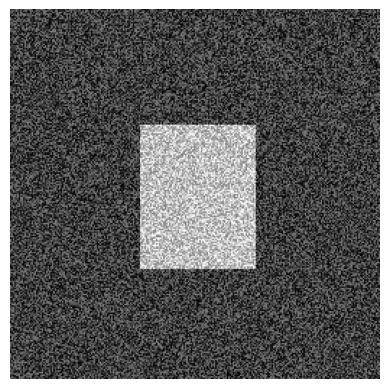

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

image = np.random.rand(256, 256)

image[80:180, 90:170] += 1

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

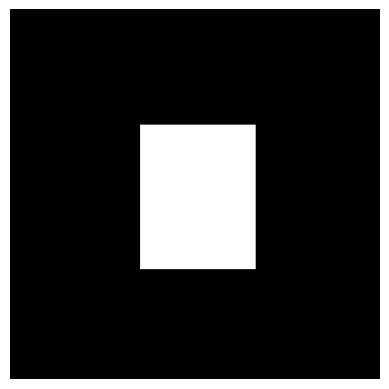

In [ ]:
mask = np.zeros((256, 256))

mask[80:180, 90:170] = 1

plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
!pip install -q kaggle

In [ ]:
import requests

url = "https://www.kaggle.com/datasets/mahmudulhasantasin/isic-2016-original-dataset"

r = requests.get(url)

print(r.status_code)
print(len(r.content))

200
12156


In [ ]:
import requests

url = "https://www.kaggle.com/api/v1/datasets/download/mahmudulhasantasin/isic-2016-original-dataset"

r = requests.get(url)

print("Status:", r.status_code)
print("Size:", len(r.content))

Status: 200
Size: 871972194


In [ ]:
with open("/content/isic2016.zip", "wb") as f:
    f.write(r.content)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
import zipfile

zip_path = "/content/isic2016.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    files = zip_ref.namelist()

print("Number of files:", len(files))
print("\nFirst 20 files:")

for file in files[:20]:
    print(file)

Number of files: 2560

First 20 files:
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000003.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000012.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000013.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000014.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000015.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000020.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000022.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000023.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000027.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000036.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000037.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000040.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000043.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000052.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000053.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000056.jpg
isic 2016/ISBI2016_ISIC_Part1_Test_Data/ISIC_0000

In [ ]:
from collections import Counter

folders = []

for file in files:
    folder = "/".join(file.split("/")[:-1])
    folders.append(folder)

for folder, count in Counter(folders).items():
    print(count, "files  →", folder)

379 files  → isic 2016/ISBI2016_ISIC_Part1_Test_Data
379 files  → isic 2016/ISBI2016_ISIC_Part1_Test_GroundTruth
900 files  → isic 2016/ISBI2016_ISIC_Part1_Training_Data
900 files  → isic 2016/ISBI2016_ISIC_Part1_Training_GroundTruth
2 files  → isic 2016


In [ ]:
for file in files:
    if "Training" in file:
        print(file)

isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000000.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000001.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000002.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000004.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000006.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000007.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000008.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000009.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000010.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000011.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000016.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000017.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000018.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000019.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000021.jpg
isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000024.jpg
isic 2016/ISBI2016_ISIC_

In [ ]:
import zipfile
import os

zip_path = "/content/isic2016.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:

    image_file = "isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000000.jpg"
    mask_file = "isic 2016/ISBI2016_ISIC_Part1_Training_GroundTruth/ISIC_0000000_Segmentation.png"

    zip_ref.extract(image_file, "/content/")
    zip_ref.extract(mask_file, "/content/")

print("Image and mask extracted successfully!")

Image and mask extracted successfully!


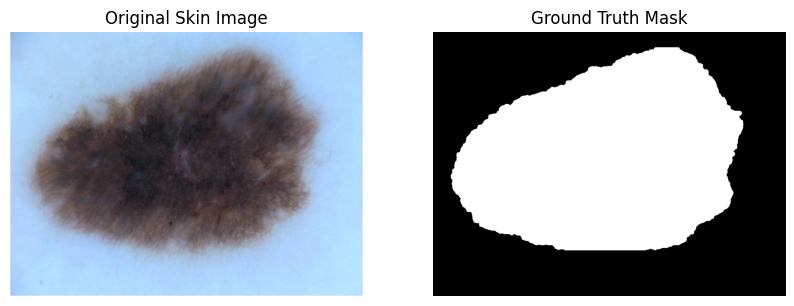

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "/content/isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000000.jpg"
mask_path = "/content/isic 2016/ISBI2016_ISIC_Part1_Training_GroundTruth/ISIC_0000000_Segmentation.png"

image = Image.open(image_path)
mask = Image.open(mask_path)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Skin Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

In [ ]:
import numpy as np

mask_array = np.array(mask)

print("Mask shape:", mask_array.shape)
print("Minimum value:", mask_array.min())
print("Maximum value:", mask_array.max())
print("Unique values:", np.unique(mask_array))

Mask shape: (767, 1022)
Minimum value: 0
Maximum value: 255
Unique values: [  0 255]


In [ ]:
lesion_pixels = np.sum(mask_array == 255)
background_pixels = np.sum(mask_array == 0)

print("Lesion pixels:", lesion_pixels)
print("Background pixels:", background_pixels)
print("Total pixels:", lesion_pixels + background_pixels)

Lesion pixels: 364956
Background pixels: 418918
Total pixels: 783874


In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("PyTorch is working!")

PyTorch version: 2.11.0+cu128
PyTorch is working!


In [2]:
import torch
import torch.nn as nn

conv = nn.Conv2d(
    in_channels=3,
    out_channels=16,
    kernel_size=3,
    padding=1
)

print(conv)

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [3]:
import numpy as np
import torch

# Convert image to a NumPy array
image_array = np.array(image)

print("Image shape:", image_array.shape)

NameError: name 'image' is not defined

In [4]:
from PIL import Image
import numpy as np

image_path = "/content/isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000000.jpg"

image = Image.open(image_path)

image_array = np.array(image)

print("Image shape:", image_array.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000000.jpg'

In [5]:
import os

print("ZIP exists:", os.path.exists("/content/isic2016.zip"))
print("Extracted folder exists:", os.path.exists("/content/isic 2016"))

ZIP exists: False
Extracted folder exists: False


In [6]:
import requests

url = "https://www.kaggle.com/api/v1/datasets/download/mahmudulhasantasin/isic-2016-original-dataset"

zip_path = "/content/isic2016.zip"

with requests.get(url, stream=True) as r:
    r.raise_for_status()

    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [7]:
import zipfile
import os

zip_path = "/content/isic2016.zip"

image_file = "isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000000.jpg"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extract(image_file, "/content/")

image_path = "/content/" + image_file

print("Image exists:", os.path.exists(image_path))
print("Image path:", image_path)

Image exists: True
Image path: /content/isic 2016/ISBI2016_ISIC_Part1_Training_Data/ISIC_0000000.jpg


In [8]:
from PIL import Image
import numpy as np

image = Image.open(image_path)
image_array = np.array(image)

print("Image shape:", image_array.shape)

Image shape: (767, 1022, 3)


In [9]:
import torch

# Convert image from NumPy to PyTorch tensor
image_tensor = torch.tensor(image_array, dtype=torch.float32)

# Change from (Height, Width, Channels)
# to (Channels, Height, Width)
image_tensor = image_tensor.permute(2, 0, 1)

# Add a batch dimension
image_tensor = image_tensor.unsqueeze(0)

print("Tensor shape:", image_tensor.shape)

Tensor shape: torch.Size([1, 3, 767, 1022])


In [10]:
feature_maps = conv(image_tensor)

print("Input shape: ", image_tensor.shape)
print("Output shape:", feature_maps.shape)

Input shape:  torch.Size([1, 3, 767, 1022])
Output shape: torch.Size([1, 16, 767, 1022])


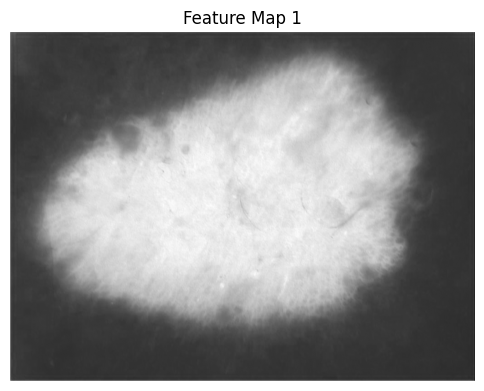

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.imshow(feature_maps[0, 0].detach().numpy(), cmap="gray")

plt.title("Feature Map 1")
plt.axis("off")

plt.show()

In [12]:
relu = nn.ReLU()

activated_features = relu(feature_maps)

print("Before ReLU:", feature_maps.shape)
print("After ReLU: ", activated_features.shape)

Before ReLU: torch.Size([1, 16, 767, 1022])
After ReLU:  torch.Size([1, 16, 767, 1022])


In [13]:
import torch.nn as nn

block = nn.Sequential(
    nn.Conv2d(
        in_channels=3,
        out_channels=16,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU()
)

print(block)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
)


In [14]:
output = block(image_tensor)

print("Input shape: ", image_tensor.shape)
print("Output shape:", output.shape)

Input shape:  torch.Size([1, 3, 767, 1022])
Output shape: torch.Size([1, 16, 767, 1022])


In [15]:
block2 = nn.Sequential(
    nn.Conv2d(
        in_channels=16,
        out_channels=32,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU()
)

print(block2)

Sequential(
  (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
)


In [16]:
features1 = block(image_tensor)
features2 = block2(features1)

print("After block 1:", features1.shape)
print("After block 2:", features2.shape)

After block 1: torch.Size([1, 16, 767, 1022])
After block 2: torch.Size([1, 32, 767, 1022])


In [17]:
pool = nn.MaxPool2d(kernel_size=2)

print(pool)

MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
